# Random Forest classification on text & handwriting corpus

Train a **TF-IDF + Random Forest** classifier on the smol-doc-analyzer synthetic insurance document corpus:

- **Typed text** — clean Stage A documents (`data/synthetic/documents/`)
- **Handwriting / OCR surface** — character-garbled noisy variants (`data/synthetic/noisy/`) that approximate OCR'd handwriting and scanned forms

**Targets**

1. Primary: predict `document_type` (ACORD-inspired taxonomy)
2. Secondary: predict surface style (`typed` vs `handwriting_ocr`)

This notebook is a lightweight classical baseline alongside the DeBERTa / ViT deep classifiers.

After evaluation, metrics (accuracy, F1, confusion matrix, per-class table) are logged to
**Weights & Biases** under project `smol-doc-analyzer` with job type `train` /
run name `rf-notebook-…`. Corpus seeding does **not** open a WandB run from this notebook.

## 1. Setup

In [2]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay

# Allow running the notebook from notebooks/ or repo root
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.classification.random_forest import (
    SURFACE_HANDWRITING_OCR,
    SURFACE_TYPED,
    assign_split_column,
    build_document_type_pipeline,
    ensure_seed_corpus,
    evaluate_classifier,
    load_text_handwriting_corpus,
    log_random_forest_to_wandb,
    save_random_forest_bundle,
    top_tfidf_feature_importances,
    write_predictions_jsonl,
)
from src.utils.config import Config
from src.utils.wandb_utils import load_wandb_settings

pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", context="notebook")
cfg = Config.load()
print("repo:", REPO_ROOT)
print("documents dir:", cfg.document_output_dir)
print("noisy dir:", cfg.noisy_output_dir)

repo: /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer
documents dir: /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/synthetic/documents
noisy dir: /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/synthetic/noisy


## 2. Ensure corpus (text + handwriting/OCR noise)

If synthetic documents are missing, regenerate a seeded corpus (template mode; no API key required).

In [3]:
SEED_N = 240
SEED = 42

# log_wandb=False: don't open a seed_pipeline WandB run from this notebook
corpus_paths = ensure_seed_corpus(n=SEED_N, seed=SEED, log_wandb=False)
display(pd.Series(corpus_paths, name="path").to_frame())

n_requested,▁
progress/noise_done,▁
progress/profiler_done,▁
progress/skeletons_done,▁
progress/stage_a_done,▁
progress/stage_b_done,▁
documents,/Users/morningstar/D...
memos,/Users/morningstar/D...
n,240
n_requested,240
noisy,/Users/morningstar/D...


,path
skeletons,/Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/synthetic/skeletons/skeletons_n240_seed42.jsonl
documents,/Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/synthetic/documents/documents_from_skeletons_n240_see...
memos,/Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/synthetic/memos/memos_from_documents_from_skeletons_n...
noisy,/Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/synthetic/noisy/noisy_from_documents_from_skeletons_n...
splits,/Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/synthetic/splits.json
generated,true


## 3. Load typed + handwriting/OCR documents

In [4]:
frame = load_text_handwriting_corpus()
frame = assign_split_column(frame)

print(f"rows: {len(frame):,}  |  unique claims: {frame['claim_id'].nunique():,}")
print("sources:", frame.attrs.get("docs_path"), "|", frame.attrs.get("noisy_path"))

display(frame["surface"].value_counts().rename("count").to_frame())
display(
    frame.groupby(["document_type", "surface"])
    .size()
    .unstack(fill_value=0)
    .assign(total=lambda d: d.sum(axis=1))
    .sort_values("total", ascending=False)
)
display(frame["split"].value_counts().rename("count").to_frame())
display(frame.head(3))

rows: 480  |  unique claims: 198
sources: /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/synthetic/documents/documents_from_skeletons_n240_seed42.jsonl | /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/synthetic/noisy/noisy_from_documents_from_skeletons_n240_seed42.jsonl


,count
surface,
typed,240
handwriting_ocr,240


surface,handwriting_ocr,typed,total
document_type,,,
loss_notice,40,40,80
claims_correspondence,38,38,76
supporting_evidence,35,35,70
repair_estimate,33,33,66
application_commercial,26,26,52
certificate_evidence,26,26,52
application_personal,22,22,44
policy_change_endorsement,20,20,40


,count
split,
train,336
val,72
test,72


,record_id,claim_id,text,document_type,surface,is_noisy,split
0,CLM-2026-763588::application_personal::0,CLM-2026-763588,PERSONAL LINES APPLICATION\nClaim Number: CLM-2026-763588\nACORD Form: 90\n\nAPPLICANT\nNamed Insured: Jordan Lewis\...,application_personal,typed,False,train
1,CLM-2023-397383::loss_notice::1,CLM-2023-397383,AUTOMOBILE LOSS NOTICE\nClaim Number: CLM-2023-397383\nACORD Form: 2\n\nINSURED\nNamed Insured: Jordan Brown\nPolicy...,loss_notice,typed,False,train
2,CLM-2025-623940::application_commercial::2,CLM-2025-623940,COMMERCIAL INSURANCE APPLICATION\nClaim Number: CLM-2025-623940\nACORD Form: 125\n\nAPPLICANT INFORMATION\nNamed Ins...,application_commercial,typed,False,val


### Sample: typed vs handwriting/OCR text

In [5]:
sample_id = frame.loc[frame["surface"] == SURFACE_TYPED, "record_id"].iloc[0]
pair = frame[frame["record_id"] == sample_id].set_index("surface")
print("record_id:", sample_id)
print("document_type:", pair.iloc[0]["document_type"])
print("\n--- TYPED ---\n")
print(pair.loc[SURFACE_TYPED, "text"][:700])
print("\n--- HANDWRITING / OCR ---\n")
print(pair.loc[SURFACE_HANDWRITING_OCR, "text"][:700])

record_id: CLM-2026-763588::application_personal::0
document_type: application_personal

--- TYPED ---

PERSONAL LINES APPLICATION
Claim Number: CLM-2026-763588
ACORD Form: 90

APPLICANT
Named Insured: Jordan Lewis
Policy Number: MN-455784-Z
State: MN
Coverage Type: commercial_general_liability
Effective Date: 2025-07-14

VEHICLE / PROPERTY
Policy Number: MN-455784-Z
Named Insured: Jordan Lewis

DRIVERS / OCCUPANTS
Policy Number: MN-455784-Z
Named Insured: Jordan Lewis

PRIOR INSURANCE
Policy Number: MN-455784-Z
Named Insured: Jordan Lewis

Applicant Signature
Prepared for claim CLM-2026-763588

--- HANDWRITING / OCR ---

P~RSO~A¤ LINES APPLICATION
Claim Number: CLM-2026-763588
ACORD Form: 90

APPLICANT
Named Insued: Jordan Lewis
Policy Number: MN-455784-Z
5tte: MN
Coverage Type: commercial_gener~l_liability
Effective Date: 2025-07-14

VEHICLE / PROPERTY
olicy Number: MN-45784-Z
 Named Insured: Jordan LewiV

DRIVMRS / OCCUPANTS
Policy Numbr: MN-455784-Z
Named Insred: Jordan Lewis

 PRI

## 4. Train Random Forest — document type classification

Features: TF-IDF unigrams + bigrams over the document text (typed and OCR surfaces together).

In [6]:
train_df = frame[frame["split"] == "train"].reset_index(drop=True)
val_df = frame[frame["split"] == "val"].reset_index(drop=True)
test_df = frame[frame["split"] == "test"].reset_index(drop=True)

# Fit on train + val (classical baseline); hold out test for final prediction
fit_df = pd.concat([train_df, val_df], ignore_index=True)

doc_clf = build_document_type_pipeline(
    n_estimators=300,
    max_features=20000,
    ngram_range=(1, 2),
    random_state=42,
)
doc_clf.fit(fit_df["text"], fit_df["document_type"])

print(f"fitted on {len(fit_df):,} rows  |  classes: {list(doc_clf.classes_)}")
print(f"TF-IDF vocabulary size: {len(doc_clf.named_steps['tfidf'].vocabulary_):,}")

fitted on 408 rows  |  classes: ['application_commercial', 'application_personal', 'certificate_evidence', 'claims_correspondence', 'loss_notice', 'policy_change_endorsement', 'repair_estimate', 'supporting_evidence']
TF-IDF vocabulary size: 4,549


## 5. Evaluate on held-out test set

In [7]:
doc_metrics = evaluate_classifier(
    doc_clf,
    test_df["text"],
    test_df["document_type"],
    labels=list(doc_clf.classes_),
)

print(f"Test accuracy : {doc_metrics['accuracy']:.4f}")
print(f"Macro F1      : {doc_metrics['macro_f1']:.4f}")
print(f"Weighted F1   : {doc_metrics['weighted_f1']:.4f}")
print(f"N test rows   : {doc_metrics['n']}")

report_df = pd.DataFrame(doc_metrics["classification_report"]).T
display(report_df.round(3))

Test accuracy : 1.0000
Macro F1      : 1.0000
Weighted F1   : 1.0000
N test rows   : 72


,precision,recall,f1-score,support
application_commercial,1.000,1.000,1.000,6.0
application_personal,1.000,1.000,1.000,8.0
certificate_evidence,0.000,0.000,0.000,0.0
claims_correspondence,1.000,1.000,1.000,6.0
loss_notice,1.000,1.000,1.000,16.0
policy_change_endorsement,1.000,1.000,1.000,12.0
repair_estimate,1.000,1.000,1.000,10.0
supporting_evidence,1.000,1.000,1.000,14.0
accuracy,1.000,1.000,1.000,1.0
macro avg,0.875,0.875,0.875,72.0


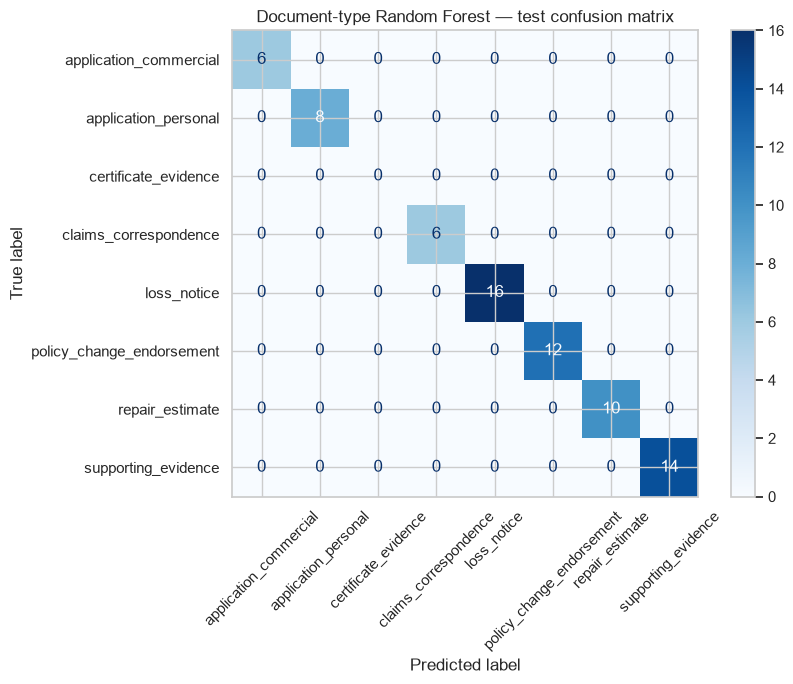

In [8]:
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(
    confusion_matrix=np.asarray(doc_metrics["confusion_matrix"]),
    display_labels=doc_metrics["labels"],
).plot(ax=ax, xticks_rotation=45, colorbar=True, cmap="Blues")
ax.set_title("Document-type Random Forest — test confusion matrix")
plt.tight_layout()
plt.show()

### Accuracy by surface (typed vs handwriting/OCR)

,surface,n,accuracy,macro_f1
0,handwriting_ocr,36,1.0,1.0
1,typed,36,1.0,1.0


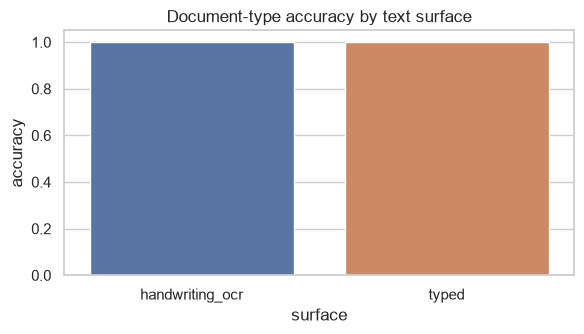

In [9]:
surface_rows = []
for surface, group in test_df.groupby("surface"):
    m = evaluate_classifier(
        doc_clf, group["text"], group["document_type"], labels=list(doc_clf.classes_)
    )
    surface_rows.append(
        {
            "surface": surface,
            "n": m["n"],
            "accuracy": m["accuracy"],
            "macro_f1": m["macro_f1"],
        }
    )
surface_metrics = pd.DataFrame(surface_rows).sort_values("surface")
display(surface_metrics.round(4))

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.barplot(data=surface_metrics, x="surface", y="accuracy", hue="surface", ax=ax, legend=False)
ax.set_ylim(0, 1.05)
ax.set_title("Document-type accuracy by text surface")
ax.set_ylabel("accuracy")
plt.tight_layout()
plt.show()

## 6. Predictions

Generate class predictions + confidence for every test document.

In [10]:
y_pred = doc_metrics["predictions"]
y_conf = doc_metrics["max_proba"]

pred_df = test_df[["record_id", "claim_id", "surface", "document_type"]].copy()
pred_df = pred_df.rename(columns={"document_type": "true_label"})
pred_df["predicted_label"] = y_pred
pred_df["confidence"] = y_conf
pred_df["correct"] = pred_df["true_label"] == pred_df["predicted_label"]

print("prediction accuracy:", round(float(pred_df["correct"].mean()), 4))
display(pred_df.head(10))

mistakes = pred_df[~pred_df["correct"]].sort_values("confidence", ascending=False)
print(f"\nmisclassified: {len(mistakes)} / {len(pred_df)}")
display(mistakes.head(10))

prediction accuracy: 1.0


,record_id,claim_id,surface,true_label,predicted_label,confidence,correct
0,CLM-2024-845743::application_personal::9,CLM-2024-845743,typed,application_personal,application_personal,0.883333,True
1,CLM-2023-230081::application_commercial::12,CLM-2023-230081,typed,application_commercial,application_commercial,0.790000,True
2,CLM-2023-627087::policy_change_endorsement::21,CLM-2023-627087,typed,policy_change_endorsement,policy_change_endorsement,0.950000,True
3,CLM-2023-287814::loss_notice::29,CLM-2023-287814,typed,loss_notice,loss_notice,0.996667,True
4,CLM-2023-611047::claims_correspondence::44,CLM-2023-611047,typed,claims_correspondence,claims_correspondence,0.990000,True
5,CLM-2023-611047::supporting_evidence::45,CLM-2023-611047,typed,supporting_evidence,supporting_evidence,1.000000,True
6,CLM-2023-033105::repair_estimate::61,CLM-2023-033105,typed,repair_estimate,repair_estimate,0.606667,True
7,CLM-2025-468437::supporting_evidence::66,CLM-2025-468437,typed,supporting_evidence,supporting_evidence,0.976667,True
8,CLM-2024-054041::policy_change_endorsement::73,CLM-2024-054041,typed,policy_change_endorsement,policy_change_endorsement,0.966667,True
9,CLM-2023-016419::supporting_evidence::78,CLM-2023-016419,typed,supporting_evidence,supporting_evidence,0.983333,True



misclassified: 0 / 72


,record_id,claim_id,surface,true_label,predicted_label,confidence,correct


## 7. Top TF-IDF features (Random Forest importance)

,feature,importance
0,named,0.013168
1,policy,0.013029
2,type,0.011652
3,is,0.011400
4,labor,0.010567
5,filed,0.010547
6,of,0.010347
7,date of,0.010279
8,reserve,0.009932
9,claim,0.009916


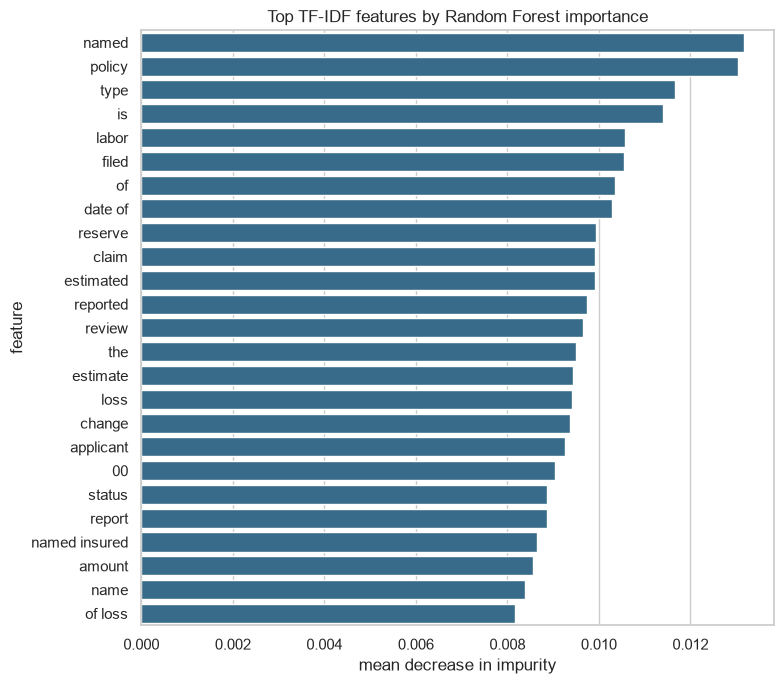

In [11]:
fi = top_tfidf_feature_importances(doc_clf, top_k=25)
display(fi)

fig, ax = plt.subplots(figsize=(8, 7))
sns.barplot(data=fi, y="feature", x="importance", color="#2a6f97", ax=ax)
ax.set_title("Top TF-IDF features by Random Forest importance")
ax.set_xlabel("mean decrease in impurity")
plt.tight_layout()
plt.show()

## 8. Secondary model — surface style (typed vs handwriting/OCR)

A second Random Forest predicts whether the text looks typed/clean or OCR/handwriting-noisy.

Surface accuracy : 0.7222
Surface macro F1 : 0.6990


,precision,recall,f1-score,support
typed,1.000,0.444,0.615,36.000
handwriting_ocr,0.643,1.000,0.783,36.000
accuracy,0.722,0.722,0.722,0.722
macro avg,0.821,0.722,0.699,72.000
weighted avg,0.821,0.722,0.699,72.000


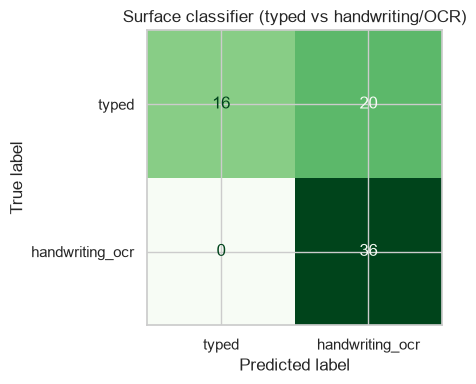

In [12]:
surface_clf = build_document_type_pipeline(
    n_estimators=200,
    max_features=15000,
    ngram_range=(1, 2),
    random_state=42,
)
surface_clf.fit(fit_df["text"], fit_df["surface"])

surface_eval = evaluate_classifier(
    surface_clf,
    test_df["text"],
    test_df["surface"],
    labels=[SURFACE_TYPED, SURFACE_HANDWRITING_OCR],
)
print(f"Surface accuracy : {surface_eval['accuracy']:.4f}")
print(f"Surface macro F1 : {surface_eval['macro_f1']:.4f}")
display(pd.DataFrame(surface_eval["classification_report"]).T.round(3))

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(
    confusion_matrix=np.asarray(surface_eval["confusion_matrix"]),
    display_labels=surface_eval["labels"],
).plot(ax=ax, colorbar=False, cmap="Greens")
ax.set_title("Surface classifier (typed vs handwriting/OCR)")
plt.tight_layout()
plt.show()

## 9. Persist models & reports

In [13]:
import joblib

out_dir = cfg.models_dir / "random_forest_classifier"
report_dir = cfg.evaluation_reports_dir
report_dir.mkdir(parents=True, exist_ok=True)

meta = {
    "task": "document_type_random_forest",
    "docs_path": frame.attrs.get("docs_path"),
    "noisy_path": frame.attrs.get("noisy_path"),
    "n_fit": int(len(fit_df)),
    "n_test": int(len(test_df)),
    "surfaces": sorted(frame["surface"].unique().tolist()),
    "n_estimators": int(doc_clf.named_steps["rf"].n_estimators),
    "tfidf_max_features": int(doc_clf.named_steps["tfidf"].max_features or 0),
    "test_accuracy": doc_metrics["accuracy"],
    "test_macro_f1": doc_metrics["macro_f1"],
    "surface_test_accuracy": surface_eval["accuracy"],
}

model_path = save_random_forest_bundle(doc_clf, out_dir, doc_metrics, meta=meta)
pred_path = write_predictions_jsonl(
    out_dir / "test_predictions.jsonl",
    record_ids=pred_df["record_id"].tolist(),
    y_true=pred_df["true_label"].tolist(),
    y_pred=pred_df["predicted_label"].tolist(),
    surfaces=pred_df["surface"].tolist(),
    confidences=pred_df["confidence"].tolist(),
)

joblib.dump(surface_clf, out_dir / "surface_random_forest_pipeline.joblib")

acc = doc_metrics["accuracy"]
macro = doc_metrics["macro_f1"]
surf_acc = surface_eval["accuracy"]
surface_lines = ["| surface | n | accuracy | macro_f1 |", "|---|---:|---:|---:|"]
for _, row in surface_metrics.iterrows():
    surface_lines.append(
        "| {surface} | {n} | {accuracy:.4f} | {macro_f1:.4f} |".format(
            surface=row["surface"],
            n=int(row["n"]),
            accuracy=row["accuracy"],
            macro_f1=row["macro_f1"],
        )
    )
surface_table = "\n".join(surface_lines)
md_report = "\n".join(
    [
        "# Random Forest classification report",
        "",
        "- Corpus: typed Stage A documents + handwriting/OCR noisy variants",
        f"- Fit rows: {len(fit_df)}",
        f"- Test rows: {len(test_df)}",
        f"- Document-type accuracy: **{acc:.4f}**",
        f"- Document-type macro F1: **{macro:.4f}**",
        f"- Surface (typed vs handwriting_ocr) accuracy: **{surf_acc:.4f}**",
        "",
        "## Accuracy by surface",
        "",
        surface_table,
        "",
        "## Artifacts",
        "",
        f"- `models/random_forest_classifier/{model_path.name}`",
        f"- `models/random_forest_classifier/{pred_path.name}`",
        "- `models/random_forest_classifier/surface_random_forest_pipeline.joblib`",
        "",
    ]
)
(report_dir / "random_forest_classification_report.md").write_text(md_report, encoding="utf-8")

print("saved model bundle ->", out_dir)
print("saved eval report  ->", report_dir / "random_forest_classification_report.md")
display(pd.Series(meta, name="value").to_frame())

# Log classifier metrics (not corpus seeding) to Weights & Biases
wb_settings = load_wandb_settings()
log_random_forest_to_wandb(
    doc_metrics=doc_metrics,
    surface_metrics=surface_eval,
    config={
        "n_estimators": int(doc_clf.named_steps["rf"].n_estimators),
        "tfidf_max_features": int(doc_clf.named_steps["tfidf"].max_features or 0),
        "n_fit": int(len(fit_df)),
        "n_test": int(len(test_df)),
        "docs_path": frame.attrs.get("docs_path"),
        "noisy_path": frame.attrs.get("noisy_path"),
        "source": "notebook",
    },
    y_true=test_df["document_type"].tolist(),
    artifact_paths=[
        out_dir / "eval_metrics.json",
        out_dir / "train_meta.json",
        report_dir / "random_forest_classification_report.md",
    ],
    wandb_settings=wb_settings,
    run_name="rf-notebook-random-forest-classifier",
)
print(
    "WandB:",
    f"enabled={wb_settings.enabled}",
    f"mode={wb_settings.mode}",
    f"project={wb_settings.project}",
)

saved model bundle -> /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/models/random_forest_classifier
saved eval report  -> /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/evaluation/reports/random_forest_classification_report.md


,value
task,document_type_random_forest
docs_path,/Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/synthetic/documents/documents_from_skeletons_n240_see...
noisy_path,/Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/synthetic/noisy/noisy_from_documents_from_skeletons_n...
n_fit,408
n_test,72
surfaces,"[handwriting_ocr, typed]"
n_estimators,300
tfidf_max_features,20000
test_accuracy,1.0
test_macro_f1,1.0


## 10. Quick inference helper

Predict document type for an arbitrary snippet (typed or OCR-like text).

In [14]:
def predict_document(text: str, model=doc_clf) -> dict:
    label = model.predict([text])[0]
    proba = model.predict_proba([text])[0]
    conf = float(proba.max())
    ranking = sorted(
        zip(model.classes_, proba),
        key=lambda x: x[1],
        reverse=True,
    )
    return {
        "predicted_label": label,
        "confidence": conf,
        "top3": [(c, float(p)) for c, p in ranking[:3]],
    }


demo = """PROPERTY LOSS NOTICE
Claim Number: CLM-2026-111222
Date of Loss: 2025-11-03
Loss Type: water
Description of Loss: Pipe burst in upstairs bathroom; ceiling damage reported.
Reported By: Jordan Lee
"""

print(predict_document(demo))

{'predicted_label': 'loss_notice', 'confidence': 0.34, 'top3': [('loss_notice', 0.34), ('application_commercial', 0.15666666666666668), ('certificate_evidence', 0.15)]}
